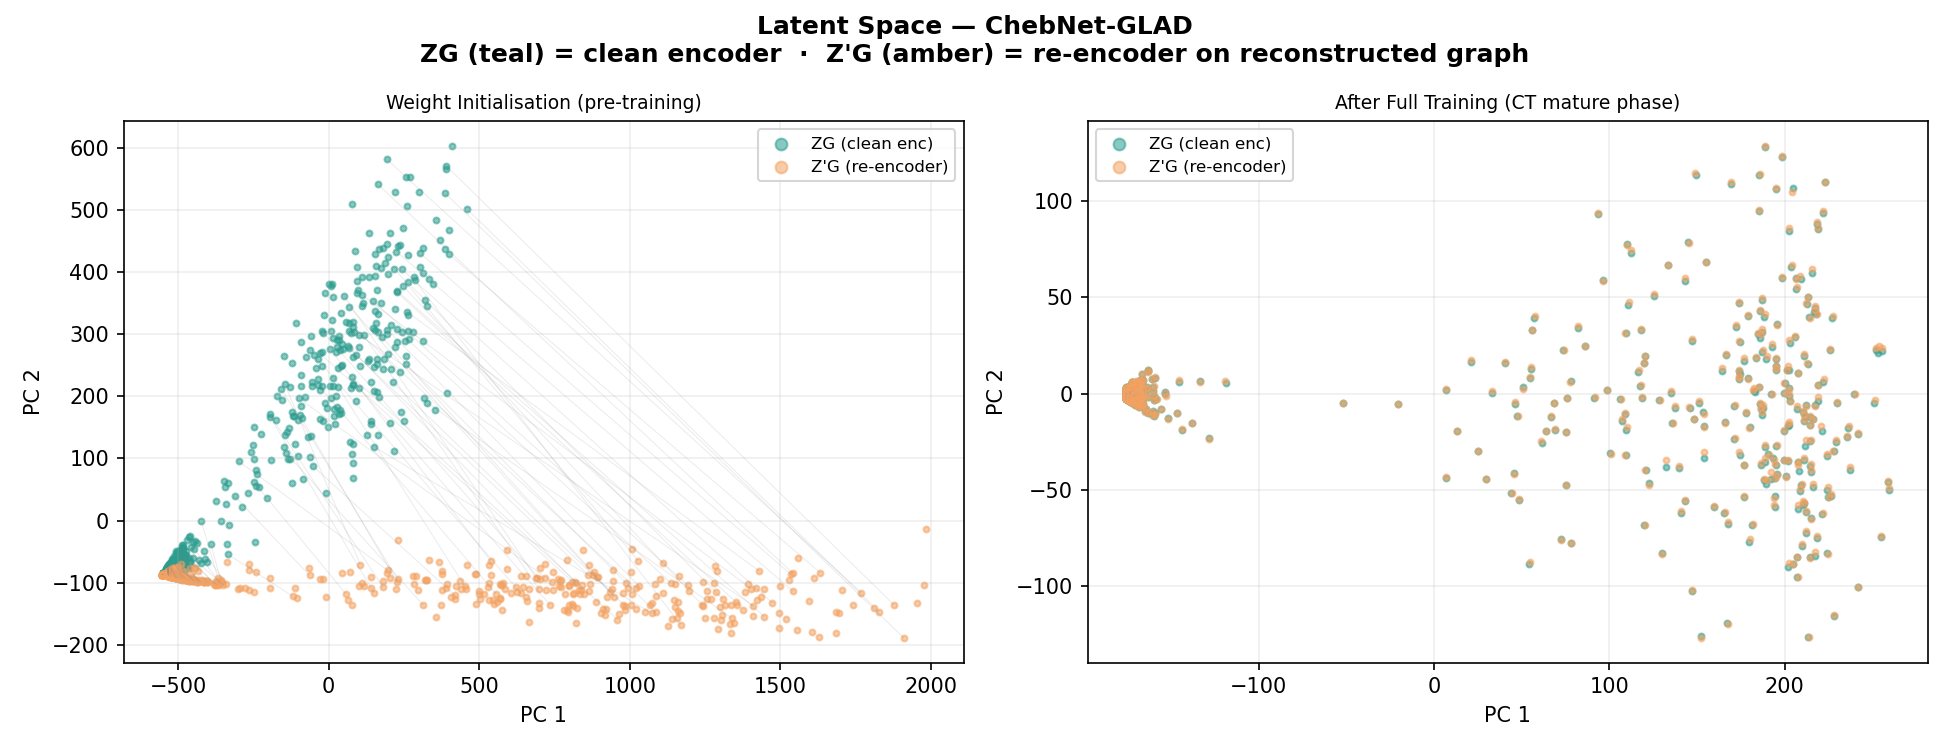
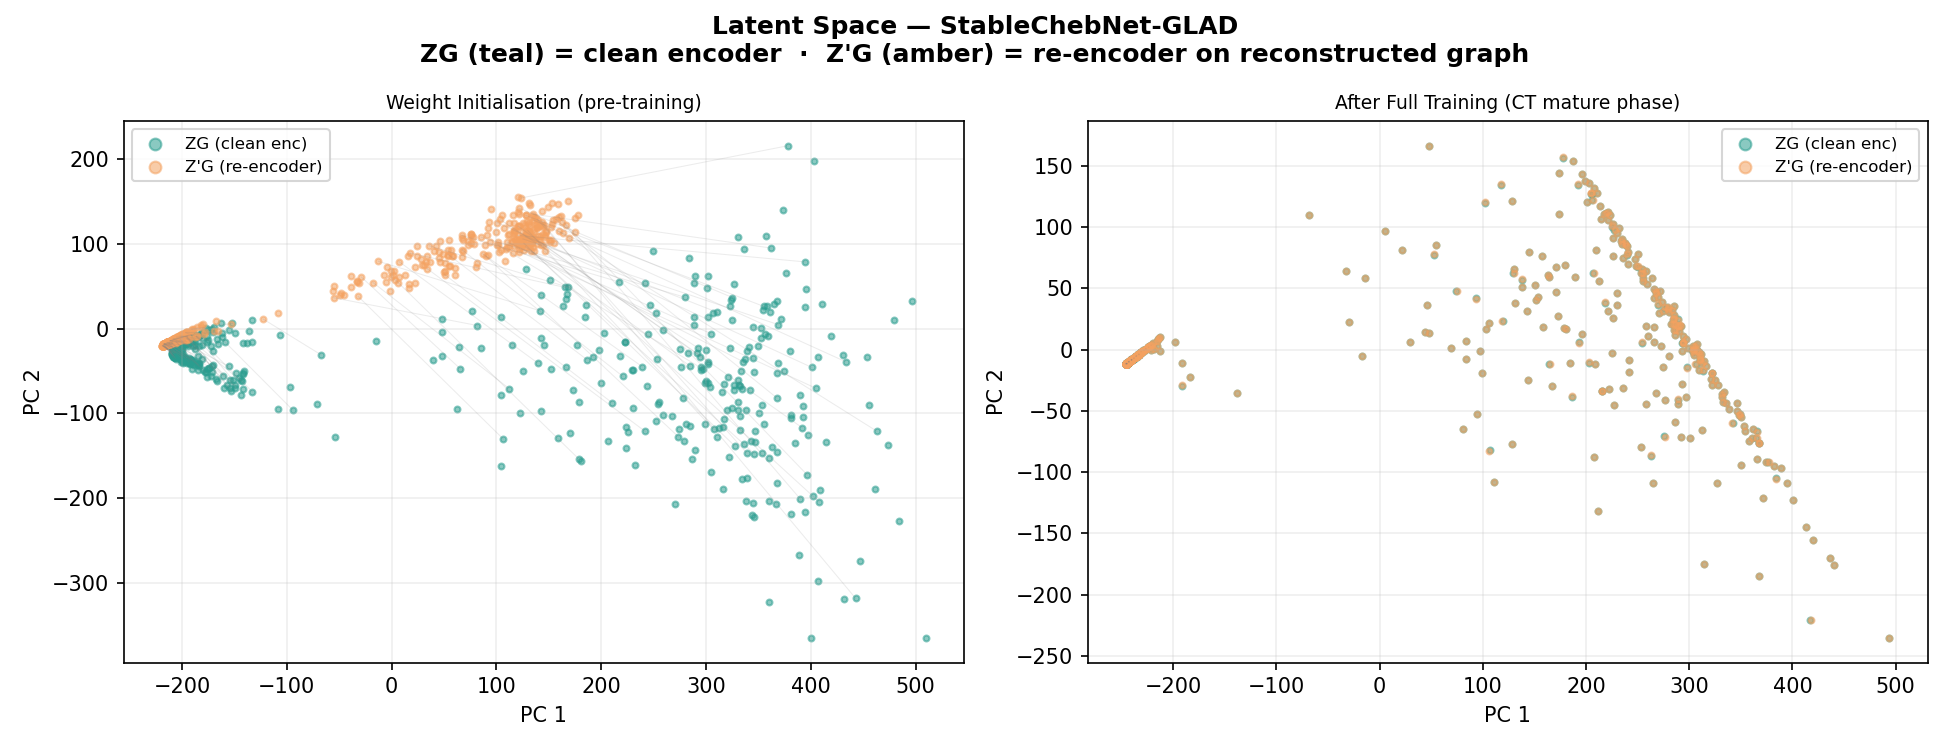
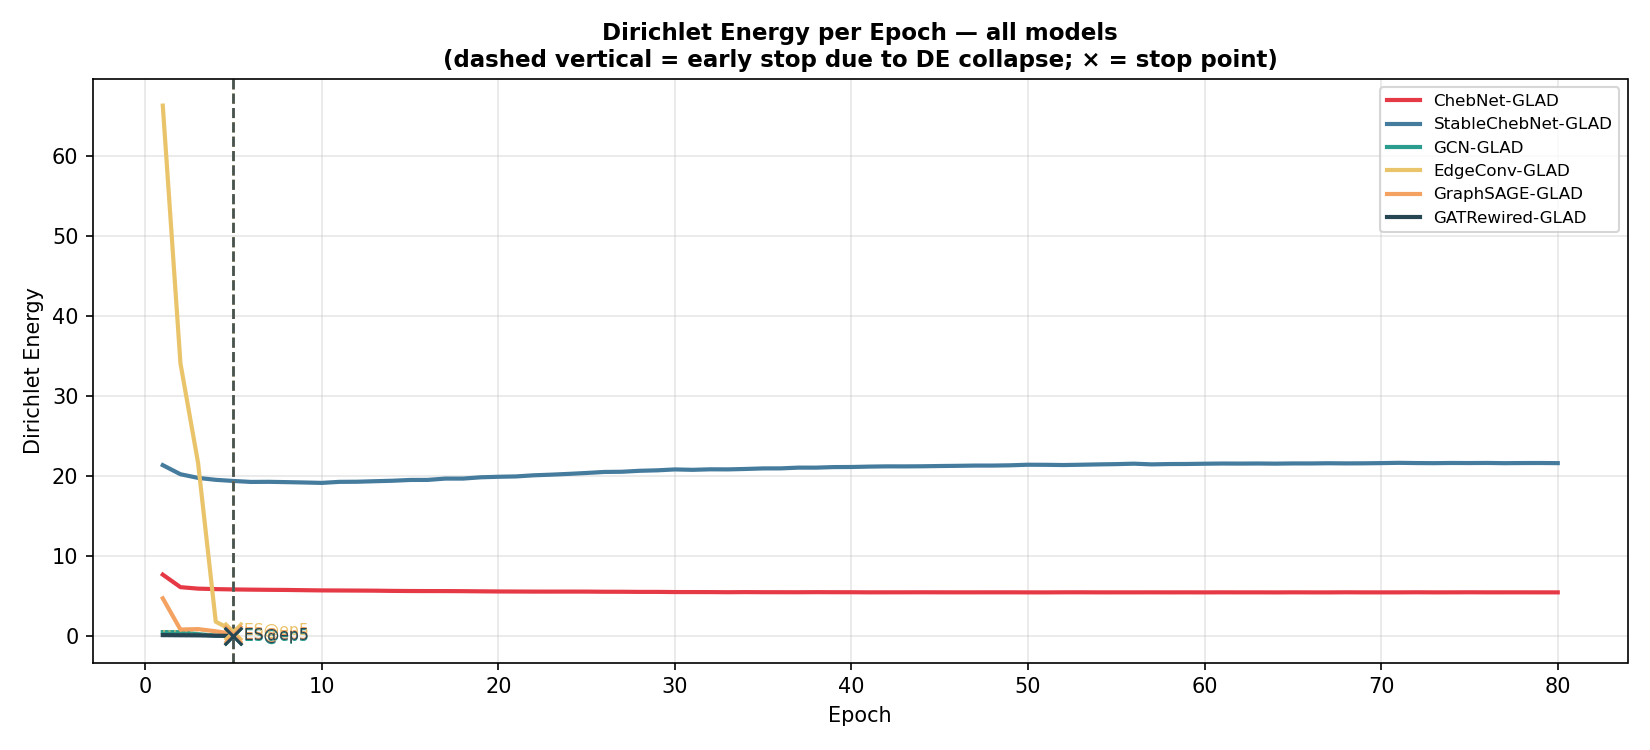
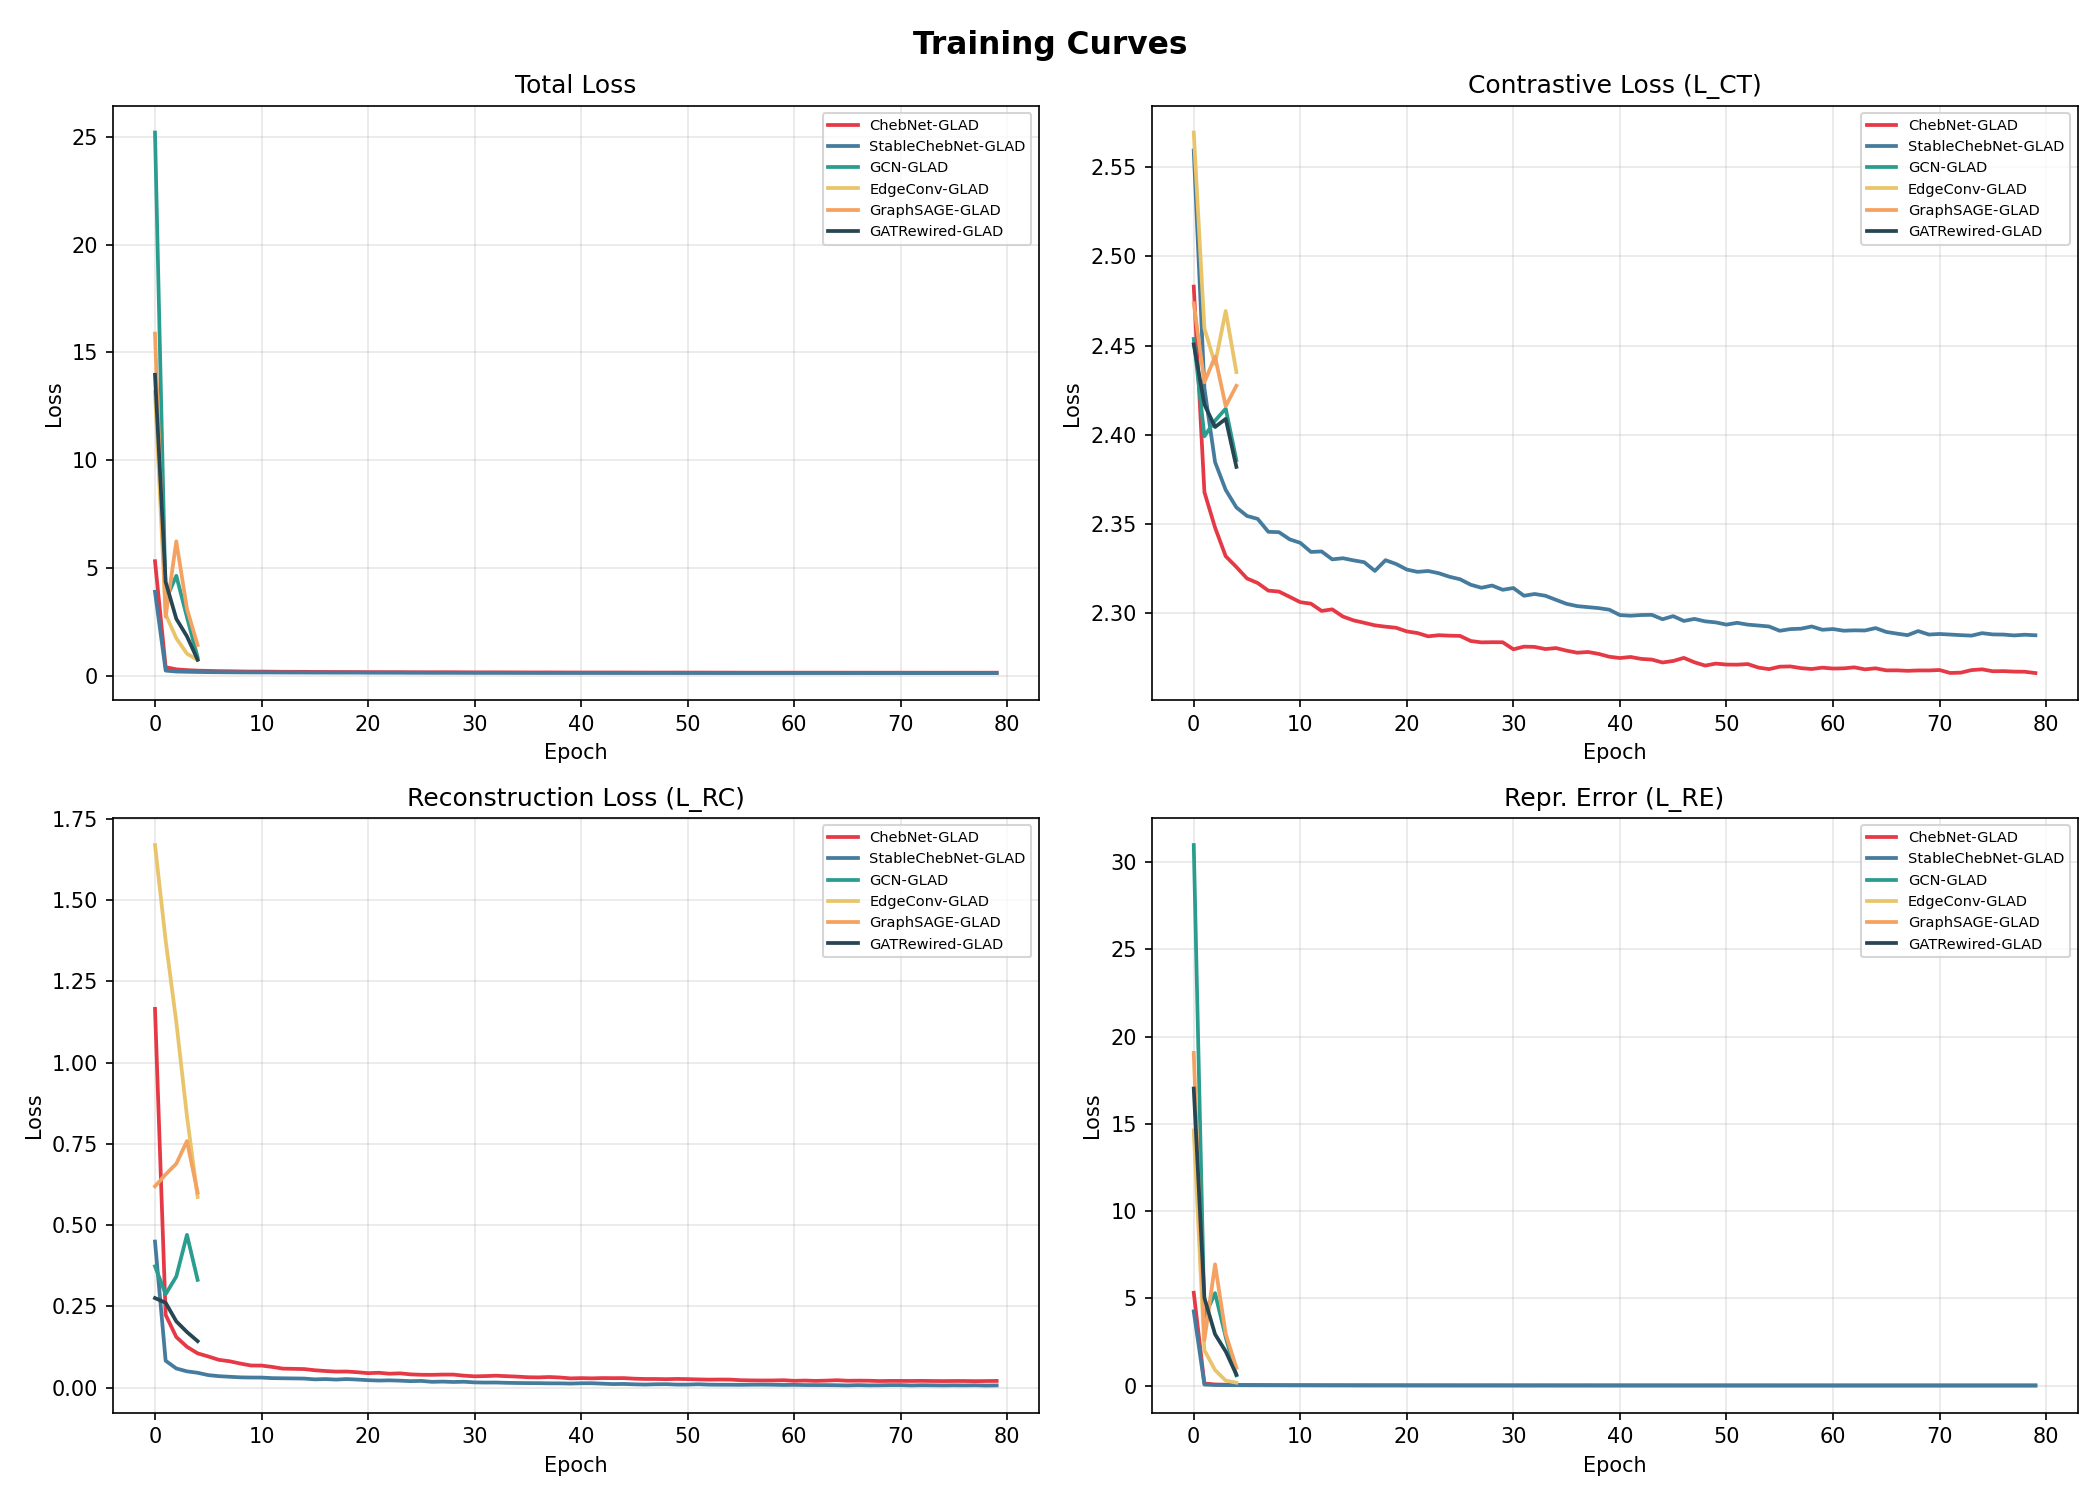

## Cell 1 — Environment & Imports

In [ ]:
import os, math, time, warnings, copy

# P100 / CUDA compute-capability 6.0 compatibility
# Must be set BEFORE torch is imported so cuBLAS picks the right path.
os.environ.setdefault("CUDA_LAUNCH_BLOCKING", "1")
os.environ.setdefault("TORCH_USE_CUDA_DSA", "0")

import torch
import torch.nn as nn
import torch.nn.functional as F

# Force float32 everywhere; fp16 is broken on P100 for many ops
torch.set_default_dtype(torch.float32)

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import (
    ChebConv, GCNConv, SAGEConv, GATConv,
    global_mean_pool, global_max_pool, global_add_pool,
    MessagePassing,
)
from torch_geometric.nn import knn_graph
from torch_geometric.utils import add_self_loops, coalesce
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.decomposition import PCA
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
print("Imports OK")

## Cell 2 — Global Config

In [ ]:
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_CHEB      = 3
HIDDEN      = 64
PROJ_DIM    = 32
EPOCHS      = 80
LR          = 3e-4
BATCH_SIZE  = 32
TAU         = 0.5
ETA         = 0.1
SIGMA       = 0.1
LAMBDA1     = 0.5
LAMBDA2     = 0.5
EPSILON     = 0.5
GAMMA       = 0.05
TEST_FRAC   = 0.20
SEED        = 42

# Early stopping
ES_PATIENCE_LOSS   = 10
ES_MIN_DELTA_LOSS  = 1e-4
ES_DE_DROP_THRESH  = 0.30
ES_DE_WINDOW       = 5

# Dynamic weight scheduler
DW_WARMUP_EPOCHS   = 10
DW_PLATEAU_WINDOW  = 5
DW_PLATEAU_THRESH  = 1e-3
DW_LAMBDA1_WARM    = 0.05
DW_LAMBDA1_FULL    = 0.70
DW_LAMBDA2_WARM    = 0.80
DW_LAMBDA2_FULL    = 0.20
DW_LAMBDA3_WARM    = 0.80
DW_LAMBDA3_FULL    = 0.20
DW_TRANSITION_SPEED= 5

PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#264653"]

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32  = False
    torch.backends.cudnn.allow_tf32        = False
    torch.backends.cudnn.deterministic     = True
    torch.backends.cudnn.benchmark         = False
    _cc = torch.cuda.get_device_capability()
    print(f"Device: {DEVICE}  (compute capability {_cc[0]}.{_cc[1]})")
else:
    print(f"Device: {DEVICE}")

## Cell 3 — Data Loading

In [ ]:
def load_dataset(path=r"D:\GLAD SCN early implementation\dataset\jets_processed.pt"):
    """
    Load preprocessed graphs.
    P100 fix: node features cast to float32; edge_index to int64.
    """
    raw        = torch.load(path, weights_only=False)
    sm_graphs  = raw["pyg_sm"][:10000]
    bsm_graphs = raw["pyg_bsm"][:1000]

    def _fix(g, label):
        if g.x is not None:
            g.x = g.x.float()
        if g.edge_index is not None:
            g.edge_index = g.edge_index.long()
        g.y = torch.tensor([label], dtype=torch.long)
        return g

    sm_graphs  = [_fix(g, 0) for g in sm_graphs]
    bsm_graphs = [_fix(g, 1) for g in bsm_graphs]

    idx_sm    = torch.randperm(len(sm_graphs))
    sm_graphs = [sm_graphs[i] for i in idx_sm]

    n_test_sm = int(len(sm_graphs) * TEST_FRAC)
    train_sm  = sm_graphs[n_test_sm:]
    test_sm   = sm_graphs[:n_test_sm]
    test_data = test_sm + list(bsm_graphs)

    print(f"  Train (SM only): {len(train_sm)} jets")
    print(f"  Test  (SM+BSM) : {len(test_data)} jets  "
          f"({len(test_sm)} SM + {len(bsm_graphs)} BSM)")

    train_loader = DataLoader(train_sm,  batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
    test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    return train_loader, test_loader


train_loader, test_loader = load_dataset()
sample = next(iter(train_loader))
IN_CH  = sample.x.size(-1)
print(f"  Input feature dim: {IN_CH}")

## Cell 4 — Shared Building Blocks

In [ ]:
def global_pool_concat(x, batch):
    """
    Concat mean, max, min, sum pooling -> (B, 4*hidden).
    P100: ensure contiguous float32 before pooling.
    """
    x      = x.contiguous().float()
    mean_p = global_mean_pool(x, batch)
    max_p  = global_max_pool(x, batch)
    sum_p  = global_add_pool(x, batch)
    min_p  = -global_max_pool(-x, batch)
    return torch.cat([mean_p, max_p, min_p, sum_p], dim=-1)


class MLPProjectionHead(nn.Module):
    """2-layer MLP: graph embedding -> contrastive projection space."""
    def __init__(self, in_dim, proj_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.BatchNorm1d(in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )
    def forward(self, x):
        return self.net(x)


def nt_xent_loss(z1, z2, temperature=TAU):
    """
    SimCLR NT-Xent loss — P100 compatible.
    Uses float additive mask instead of bool indexing (cc6.0 safe).
    """
    N   = z1.size(0)
    z1  = F.normalize(z1.float(), dim=-1)
    z2  = F.normalize(z2.float(), dim=-1)
    z   = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.t()) / temperature

    pos_mask  = torch.zeros(2*N, 2*N, dtype=torch.float32, device=z.device)
    idx       = torch.arange(N, device=z.device)
    pos_mask[idx, idx + N] = 1.0
    pos_mask[idx + N, idx] = 1.0
    self_mask = torch.eye(2*N, dtype=torch.float32, device=z.device) * (-1e9)

    log_sum_exp = torch.logsumexp(sim + self_mask, dim=1)
    pos_sim     = (sim * pos_mask).sum(dim=1)
    return (-pos_sim + log_sum_exp).mean()


def structure_decoder(z_node, edge_index):
    """Inner-product structure decoder -> sigmoid edge scores."""
    src    = edge_index[0]
    dst    = edge_index[1]
    logits = (z_node[src].float() * z_node[dst].float()).sum(dim=-1)
    return torch.sigmoid(logits)


def dirichlet_energy(x, edge_index, batch):
    """
    DE = mean over graphs of mean_{(i,j) in E} ||z_i - z_j||^2.

    Computed on z_node (GNN output), NOT raw inputs.
    → Changes every epoch as GNN weights update → embeddings change.

    EdgeConv resists over-smoothing because its messages encode
    differences (h_j - h_i), so its DE stays higher / more stable
    than aggregation-based GNNs, but it still varies with weights.

    P100: explicit float32 accumulators + long index cast.
    """
    src        = edge_index[0]
    dst        = edge_index[1]
    diff       = x[src] - x[dst]
    energy     = (diff * diff).sum(dim=-1)
    num_graphs = int(batch.max().item()) + 1
    src_graph  = batch[src].long()
    de     = torch.zeros(num_graphs, dtype=torch.float32, device=x.device)
    counts = torch.zeros(num_graphs, dtype=torch.float32, device=x.device)
    de.scatter_add_(0, src_graph, energy.float())
    counts.scatter_add_(0, src_graph,
                        torch.ones(src_graph.size(0), dtype=torch.float32, device=x.device))
    return (de / counts.clamp(min=1.0)).mean().item()


def perturb_weights(module, eta=ETA, sigma=SIGMA):
    """Add Gaussian noise eta*N(0,sigma^2) to all parameters in-place."""
    with torch.no_grad():
        for p in module.parameters():
            p.data.add_(eta * torch.randn_like(p.data) * sigma)


print("Building blocks defined.")

## Cell 5 — Dynamic Loss Scheduler & Early Stopping

In [ ]:
class DynamicLossScheduler:
    """
    Ltotal(t) = λ1(t)·L_CT + λ2(t)·L_RC + λ3(t)·L_RE

    Phase 1 warm-up  : high λ2(RC) + λ3(RE), low λ1(CT)
      → model learns stable representations of normal graphs first.
    Phase 2 transition: triggered when both L_RC and L_RE plateau.
    Phase 3 mature   : λ1(CT) at full weight; λ2, λ3 reduced.
    """
    def __init__(self):
        self.rc_history       = []
        self.re_history       = []
        self.phase            = "warmup"
        self.transition_start = None
        self.phase_history    = []
        self.lam1 = DW_LAMBDA1_WARM
        self.lam2 = DW_LAMBDA2_WARM
        self.lam3 = DW_LAMBDA3_WARM

    def _plateau(self, h):
        if len(h) < DW_PLATEAU_WINDOW:
            return False
        r = h[-DW_PLATEAU_WINDOW:]
        return abs(r[0] - r[-1]) / (abs(r[0]) + 1e-8) < DW_PLATEAU_THRESH

    def step(self, epoch, l_rc, l_re):
        self.rc_history.append(l_rc)
        self.re_history.append(l_re)
        if self.phase == "warmup":
            if (epoch >= DW_WARMUP_EPOCHS
                    and self._plateau(self.rc_history)
                    and self._plateau(self.re_history)):
                self.phase            = "transition"
                self.transition_start = epoch
                print(f"\n  [DynWeights] Ep {epoch}: L_RC & L_RE plateaued → CT ramp-up")
        if self.phase == "transition":
            t = min((epoch - self.transition_start + 1) / max(DW_TRANSITION_SPEED, 1), 1.0)
            self.lam1 = DW_LAMBDA1_WARM + t * (DW_LAMBDA1_FULL - DW_LAMBDA1_WARM)
            self.lam2 = DW_LAMBDA2_WARM + t * (DW_LAMBDA2_FULL - DW_LAMBDA2_WARM)
            self.lam3 = DW_LAMBDA3_WARM + t * (DW_LAMBDA3_FULL - DW_LAMBDA3_WARM)
            if t >= 1.0:
                self.phase = "mature"
                print(f"  [DynWeights] Ep {epoch}: mature phase reached")
        self.phase_history.append(self.phase)
        return self.lam1, self.lam2, self.lam3

    def get_weights(self):
        return self.lam1, self.lam2, self.lam3


class EarlyStopping:
    """
    Stops if EITHER:
      (a) total loss doesn't improve > min_delta for `patience` epochs, OR
      (b) Dirichlet energy drops > de_drop_thresh relative to its peak
          (signals over-smoothing collapse).
    """
    def __init__(self):
        self.best_loss    = float("inf")
        self.counter      = 0
        self.de_history   = []
        self.de_peak      = -float("inf")
        self.stopped      = False
        self.stop_reason  = ""

    def step(self, total_loss, de_val):
        # (a) loss plateau
        if total_loss < self.best_loss - ES_MIN_DELTA_LOSS:
            self.best_loss = total_loss
            self.counter   = 0
        else:
            self.counter += 1
        if self.counter >= ES_PATIENCE_LOSS:
            self.stopped     = True
            self.stop_reason = f"loss plateau ({ES_PATIENCE_LOSS} epochs)"
        # (b) DE collapse
        self.de_history.append(de_val)
        self.de_peak = max(self.de_peak, de_val)
        if len(self.de_history) >= ES_DE_WINDOW:
            recent_min   = min(self.de_history[-ES_DE_WINDOW:])
            relative_drop = (self.de_peak - recent_min) / (self.de_peak + 1e-8)
            if relative_drop > ES_DE_DROP_THRESH:
                self.stopped     = True
                self.stop_reason = (f"DE collapse: dropped {relative_drop:.1%} "
                                    f"from peak {self.de_peak:.4f}")
        if self.stopped:
            print(f"\n  [EarlyStopping] {self.stop_reason}")
        return self.stopped


print("Schedulers defined.")

## Cell 6 — Latent Space Collector

In [ ]:
class LatentSpaceCollector:
    """
    Collects two snapshots for ChebNet & StableChebNet:
      'init'  — before any training (random weight initialisation)
      'final' — after full training (mature contrastive phase)

    Expected result (per GSoC proposal): both snapshots look similar
    because L_RC already pulls ZG and Z'G together; CT refines geometry
    but doesn't drastically reshape the latent space.
    """
    def __init__(self):
        self.snapshots = {}

    @torch.no_grad()
    def collect(self, tag, model, loader, device):
        model.eval()
        ZG_list, ZGp_list, labels_list = [], [], []
        for data in loader:
            data = data.to(device)
            if data.x is None or data.x.size(0) == 0:
                continue
            data.x = data.x.float()
            if data.edge_index is not None:
                data.edge_index = data.edge_index.long()
            try:
                out = model(data)
            except Exception:
                continue
            ZG_list.append(out["ZG"].cpu().numpy())
            ZGp_list.append(out["ZG_prime"].cpu().numpy())
            labels_list.append(data.y.cpu().numpy().flatten()[:out["ZG"].size(0)])
        if not ZG_list:
            return
        self.snapshots[tag] = {
            "ZG":       np.concatenate(ZG_list),
            "ZG_prime": np.concatenate(ZGp_list),
            "labels":   np.concatenate(labels_list),
        }
        n = len(self.snapshots[tag]['labels'])
        print(f"  [LatentCollector] '{tag}' saved ({n} graphs)")


print("LatentSpaceCollector defined.")

## Cell 7 — GNN Model Definitions

In [ ]:
# ================================================================
# 3.A  ChebNet GLAD
# ================================================================

class ChebEncoderBlock(nn.Module):
    def __init__(self, in_channels, hidden, K=K_CHEB):
        super().__init__()
        self.conv1 = ChebConv(in_channels, hidden, K)
        self.conv2 = ChebConv(hidden,      hidden, K)
        self.conv3 = ChebConv(hidden,      hidden, K)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.bn3   = nn.BatchNorm1d(hidden)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return x, global_pool_concat(x, batch)


class ChebAttrDecoder(nn.Module):
    def __init__(self, hidden, out_channels, K=K_CHEB):
        super().__init__()
        self.conv1 = ChebConv(hidden, hidden,       K)
        self.conv2 = ChebConv(hidden, out_channels, K)

    def forward(self, z, edge_index):
        return self.conv2(F.relu(self.conv1(z, edge_index)), edge_index)


class ChebNetGLAD(nn.Module):
    def __init__(self, in_channels, hidden=HIDDEN, proj_dim=PROJ_DIM, K=K_CHEB):
        super().__init__()
        self.in_channels = in_channels
        self.hidden      = hidden
        self.K           = K
        self.encoder     = ChebEncoderBlock(in_channels, hidden, K)
        self.proj_head   = MLPProjectionHead(4 * hidden, proj_dim)
        self.attr_dec    = ChebAttrDecoder(hidden, in_channels, K)

    def encode(self, x, edge_index, batch):
        return self.encoder(x, edge_index, batch)

    def forward(self, data, lam1=LAMBDA1, lam2=LAMBDA2, lam3=LAMBDA2):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        z_node, Z_G  = self.encode(x, edge_index, batch)
        Z_prime_G    = self.proj_head(Z_G)
        p_enc = ChebEncoderBlock(self.in_channels, self.hidden, self.K).to(x.device)
        p_enc.load_state_dict(self.encoder.state_dict())
        perturb_weights(p_enc)
        with torch.no_grad():
            _, Z_pp_G = p_enc(x, edge_index, batch)
        Z_prime_pert = self.proj_head(Z_pp_G)
        A_hat  = structure_decoder(z_node, edge_index)
        X_hat  = self.attr_dec(z_node, edge_index)
        L_RC   = (F.binary_cross_entropy(A_hat, torch.ones_like(A_hat))
                  + F.mse_loss(X_hat, x))
        L_CT   = nt_xent_loss(Z_prime_G, Z_prime_pert)
        z_node_r, Z_G_r = self.encode(X_hat.detach(), edge_index, batch)
        L_RE    = F.mse_loss(Z_G, Z_G_r) + F.mse_loss(z_node, z_node_r)
        L_total = lam1 * L_CT + lam2 * L_RC + lam3 * L_RE
        per_node_re   = ((z_node - z_node_r) ** 2).sum(dim=-1)
        score_node    = global_add_pool(per_node_re.unsqueeze(-1), batch).squeeze(-1)
        anomaly_score = score_node + ((Z_G - Z_G_r) ** 2).sum(dim=-1)
        return {
            "loss": L_total, "L_CT": L_CT.item(), "L_RC": L_RC.item(),
            "L_RE": L_RE.item(), "anomaly_score": anomaly_score.detach(),
            "z_node": z_node, "edge_index": edge_index, "batch": batch,
            "ZG": Z_G.detach(), "ZG_prime": Z_G_r.detach(),
        }


# ================================================================
# 3.B  Stable-ChebNet GLAD
# ================================================================

class StableChebLayer(nn.Module):
    """
    X^{l+1} = X^l + eps * sum_k T_k(L~) X^l (W_k - W_k^T - gamma*I)
    P100: gamma*I stored as a registered buffer; uses .t() not .T
    """
    def __init__(self, channels, K=K_CHEB, epsilon=EPSILON, gamma=GAMMA):
        super().__init__()
        self.K        = K
        self.epsilon  = epsilon
        self.gamma    = gamma
        self.channels = channels
        self.W_raw = nn.ParameterList([
            nn.Parameter(torch.randn(channels, channels) * 0.01)
            for _ in range(K + 1)
        ])
        self.cheb_convs = nn.ModuleList([
            ChebConv(channels, channels, k + 1) for k in range(K + 1)
        ])
        self.bn = nn.BatchNorm1d(channels)
        self.register_buffer("eye", torch.eye(channels, dtype=torch.float32))

    def forward(self, x, edge_index):
        agg = torch.zeros_like(x)
        for k in range(self.K + 1):
            Tk_X = self.cheb_convs[k](x, edge_index)
            W_k  = self.W_raw[k]
            W_as = W_k - W_k.t() - self.gamma * self.eye
            agg  = agg + Tk_X @ W_as
        return F.relu(self.bn(x + self.epsilon * agg))


class StableChebEncoderBlock(nn.Module):
    def __init__(self, in_channels, hidden, K=K_CHEB):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, hidden)
        self.layer1     = StableChebLayer(hidden, K)
        self.layer2     = StableChebLayer(hidden, K)
        self.layer3     = StableChebLayer(hidden, K)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.input_proj(x))
        x = self.layer1(x, edge_index)
        x = self.layer2(x, edge_index)
        x = self.layer3(x, edge_index)
        return x, global_pool_concat(x, batch)


class StableChebAttrDecoder(nn.Module):
    def __init__(self, hidden, out_channels, K=K_CHEB):
        super().__init__()
        self.layer1   = StableChebLayer(hidden, K)
        self.layer2   = StableChebLayer(hidden, K)
        self.out_proj = nn.Linear(hidden, out_channels)

    def forward(self, z, edge_index):
        return self.out_proj(self.layer2(self.layer1(z, edge_index), edge_index))


class StableChebNetGLAD(nn.Module):
    def __init__(self, in_channels, hidden=HIDDEN, proj_dim=PROJ_DIM, K=K_CHEB):
        super().__init__()
        self.in_channels = in_channels
        self.hidden      = hidden
        self.K           = K
        self.encoder     = StableChebEncoderBlock(in_channels, hidden, K)
        self.proj_head   = MLPProjectionHead(4 * hidden, proj_dim)
        self.attr_dec    = StableChebAttrDecoder(hidden, in_channels, K)

    def encode(self, x, edge_index, batch):
        return self.encoder(x, edge_index, batch)

    def forward(self, data, lam1=LAMBDA1, lam2=LAMBDA2, lam3=LAMBDA2):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        z_node, Z_G  = self.encode(x, edge_index, batch)
        Z_prime_G    = self.proj_head(Z_G)
        p_enc = StableChebEncoderBlock(self.in_channels, self.hidden, self.K).to(x.device)
        p_enc.load_state_dict(self.encoder.state_dict())
        perturb_weights(p_enc)
        with torch.no_grad():
            _, Z_pp_G = p_enc(x, edge_index, batch)
        Z_prime_pert = self.proj_head(Z_pp_G)
        A_hat  = structure_decoder(z_node, edge_index)
        X_hat  = self.attr_dec(z_node, edge_index)
        L_RC   = (F.binary_cross_entropy(A_hat, torch.ones_like(A_hat))
                  + F.mse_loss(X_hat, x))
        L_CT   = nt_xent_loss(Z_prime_G, Z_prime_pert)
        z_node_r, Z_G_r = self.encode(X_hat.detach(), edge_index, batch)
        L_RE    = F.mse_loss(Z_G, Z_G_r) + F.mse_loss(z_node, z_node_r)
        L_total = lam1 * L_CT + lam2 * L_RC + lam3 * L_RE
        per_node_re   = ((z_node - z_node_r) ** 2).sum(dim=-1)
        score_node    = global_add_pool(per_node_re.unsqueeze(-1), batch).squeeze(-1)
        anomaly_score = score_node + ((Z_G - Z_G_r) ** 2).sum(dim=-1)
        return {
            "loss": L_total, "L_CT": L_CT.item(), "L_RC": L_RC.item(),
            "L_RE": L_RE.item(), "anomaly_score": anomaly_score.detach(),
            "z_node": z_node, "edge_index": edge_index, "batch": batch,
            "ZG": Z_G.detach(), "ZG_prime": Z_G_r.detach(),
        }


# ================================================================
# 3.C  GCN GLAD
# ================================================================

class GCNEncoderBlock(nn.Module):
    def __init__(self, in_channels, hidden):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden,      hidden)
        self.conv3 = GCNConv(hidden,      hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.bn3   = nn.BatchNorm1d(hidden)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return x, global_pool_concat(x, batch)


class GCNAttrDecoder(nn.Module):
    def __init__(self, hidden, out_channels):
        super().__init__()
        self.conv1 = GCNConv(hidden, hidden)
        self.conv2 = GCNConv(hidden, out_channels)

    def forward(self, z, edge_index):
        return self.conv2(F.relu(self.conv1(z, edge_index)), edge_index)


class GCNGLAD(nn.Module):
    def __init__(self, in_channels, hidden=HIDDEN, proj_dim=PROJ_DIM):
        super().__init__()
        self.in_channels = in_channels
        self.hidden      = hidden
        self.encoder     = GCNEncoderBlock(in_channels, hidden)
        self.proj_head   = MLPProjectionHead(4 * hidden, proj_dim)
        self.attr_dec    = GCNAttrDecoder(hidden, in_channels)

    def encode(self, x, edge_index, batch):
        return self.encoder(x, edge_index, batch)

    def forward(self, data, lam1=LAMBDA1, lam2=LAMBDA2, lam3=LAMBDA2):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        z_node, Z_G  = self.encode(x, edge_index, batch)
        Z_prime_G    = self.proj_head(Z_G)
        p_enc = GCNEncoderBlock(self.in_channels, self.hidden).to(x.device)
        p_enc.load_state_dict(self.encoder.state_dict())
        perturb_weights(p_enc)
        with torch.no_grad():
            _, Z_pp_G = p_enc(x, edge_index, batch)
        Z_prime_pert = self.proj_head(Z_pp_G)
        A_hat  = structure_decoder(z_node, edge_index)
        X_hat  = self.attr_dec(z_node, edge_index)
        L_RC   = (F.binary_cross_entropy(A_hat, torch.ones_like(A_hat))
                  + F.mse_loss(X_hat, x))
        L_CT   = nt_xent_loss(Z_prime_G, Z_prime_pert)
        z_node_r, Z_G_r = self.encode(X_hat.detach(), edge_index, batch)
        L_RE    = F.mse_loss(Z_G, Z_G_r) + F.mse_loss(z_node, z_node_r)
        L_total = lam1 * L_CT + lam2 * L_RC + lam3 * L_RE
        per_node_re   = ((z_node - z_node_r) ** 2).sum(dim=-1)
        score_node    = global_add_pool(per_node_re.unsqueeze(-1), batch).squeeze(-1)
        anomaly_score = score_node + ((Z_G - Z_G_r) ** 2).sum(dim=-1)
        return {"loss": L_total, "L_CT": L_CT.item(), "L_RC": L_RC.item(),
                "L_RE": L_RE.item(), "anomaly_score": anomaly_score.detach(),
                "z_node": z_node, "edge_index": edge_index, "batch": batch,
                "ZG": Z_G.detach(), "ZG_prime": Z_G_r.detach()}


# ================================================================
# 3.D  EdgeConv GLAD  (2-layer; message encodes hj-hi differences
#                     → structurally resists over-smoothing)
# ================================================================

class EdgeConvLayer(MessagePassing):
    """h_i = max_{j in N(i)} MLP([h_i || h_j - h_i])"""
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr="max")
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_channels, out_channels),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Linear(out_channels, out_channels),
        )

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)

    def message(self, x_i, x_j):
        return self.mlp(torch.cat([x_i, x_j - x_i], dim=-1))


class EdgeConvEncoderBlock(nn.Module):
    def __init__(self, in_channels, hidden):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, hidden)
        self.conv1      = EdgeConvLayer(hidden, hidden)
        self.conv2      = EdgeConvLayer(hidden, hidden)
        self.bn1        = nn.BatchNorm1d(hidden)
        self.bn2        = nn.BatchNorm1d(hidden)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.input_proj(x))
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        return x, global_pool_concat(x, batch)


class EdgeConvAttrDecoder(nn.Module):
    def __init__(self, hidden, out_channels):
        super().__init__()
        self.conv1 = EdgeConvLayer(hidden, hidden)
        self.conv2 = EdgeConvLayer(hidden, out_channels)

    def forward(self, z, edge_index):
        return self.conv2(F.relu(self.conv1(z, edge_index)), edge_index)


class EdgeConvGLAD(nn.Module):
    def __init__(self, in_channels, hidden=HIDDEN, proj_dim=PROJ_DIM):
        super().__init__()
        self.in_channels = in_channels
        self.hidden      = hidden
        self.encoder     = EdgeConvEncoderBlock(in_channels, hidden)
        self.proj_head   = MLPProjectionHead(4 * hidden, proj_dim)
        self.attr_dec    = EdgeConvAttrDecoder(hidden, in_channels)

    def encode(self, x, edge_index, batch):
        return self.encoder(x, edge_index, batch)

    def forward(self, data, lam1=LAMBDA1, lam2=LAMBDA2, lam3=LAMBDA2):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        z_node, Z_G  = self.encode(x, edge_index, batch)
        Z_prime_G    = self.proj_head(Z_G)
        p_enc = EdgeConvEncoderBlock(self.in_channels, self.hidden).to(x.device)
        p_enc.load_state_dict(self.encoder.state_dict())
        perturb_weights(p_enc)
        with torch.no_grad():
            _, Z_pp_G = p_enc(x, edge_index, batch)
        Z_prime_pert = self.proj_head(Z_pp_G)
        A_hat  = structure_decoder(z_node, edge_index)
        X_hat  = self.attr_dec(z_node, edge_index)
        L_RC   = (F.binary_cross_entropy(A_hat, torch.ones_like(A_hat))
                  + F.mse_loss(X_hat, x))
        L_CT   = nt_xent_loss(Z_prime_G, Z_prime_pert)
        z_node_r, Z_G_r = self.encode(X_hat.detach(), edge_index, batch)
        L_RE    = F.mse_loss(Z_G, Z_G_r) + F.mse_loss(z_node, z_node_r)
        L_total = lam1 * L_CT + lam2 * L_RC + lam3 * L_RE
        per_node_re   = ((z_node - z_node_r) ** 2).sum(dim=-1)
        score_node    = global_add_pool(per_node_re.unsqueeze(-1), batch).squeeze(-1)
        anomaly_score = score_node + ((Z_G - Z_G_r) ** 2).sum(dim=-1)
        return {"loss": L_total, "L_CT": L_CT.item(), "L_RC": L_RC.item(),
                "L_RE": L_RE.item(), "anomaly_score": anomaly_score.detach(),
                "z_node": z_node, "edge_index": edge_index, "batch": batch,
                "ZG": Z_G.detach(), "ZG_prime": Z_G_r.detach()}


# ================================================================
# 3.E  GraphSAGE GLAD
# ================================================================

class SAGEEncoderBlock(nn.Module):
    def __init__(self, in_channels, hidden):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden,      hidden)
        self.conv3 = SAGEConv(hidden,      hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.bn2   = nn.BatchNorm1d(hidden)
        self.bn3   = nn.BatchNorm1d(hidden)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return x, global_pool_concat(x, batch)


class SAGEAttrDecoder(nn.Module):
    def __init__(self, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(hidden, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)

    def forward(self, z, edge_index):
        return self.conv2(F.relu(self.conv1(z, edge_index)), edge_index)


class GraphSAGEGLAD(nn.Module):
    def __init__(self, in_channels, hidden=HIDDEN, proj_dim=PROJ_DIM):
        super().__init__()
        self.in_channels = in_channels
        self.hidden      = hidden
        self.encoder     = SAGEEncoderBlock(in_channels, hidden)
        self.proj_head   = MLPProjectionHead(4 * hidden, proj_dim)
        self.attr_dec    = SAGEAttrDecoder(hidden, in_channels)

    def encode(self, x, edge_index, batch):
        return self.encoder(x, edge_index, batch)

    def forward(self, data, lam1=LAMBDA1, lam2=LAMBDA2, lam3=LAMBDA2):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        z_node, Z_G  = self.encode(x, edge_index, batch)
        Z_prime_G    = self.proj_head(Z_G)
        p_enc = SAGEEncoderBlock(self.in_channels, self.hidden).to(x.device)
        p_enc.load_state_dict(self.encoder.state_dict())
        perturb_weights(p_enc)
        with torch.no_grad():
            _, Z_pp_G = p_enc(x, edge_index, batch)
        Z_prime_pert = self.proj_head(Z_pp_G)
        A_hat  = structure_decoder(z_node, edge_index)
        X_hat  = self.attr_dec(z_node, edge_index)
        L_RC   = (F.binary_cross_entropy(A_hat, torch.ones_like(A_hat))
                  + F.mse_loss(X_hat, x))
        L_CT   = nt_xent_loss(Z_prime_G, Z_prime_pert)
        z_node_r, Z_G_r = self.encode(X_hat.detach(), edge_index, batch)
        L_RE    = F.mse_loss(Z_G, Z_G_r) + F.mse_loss(z_node, z_node_r)
        L_total = lam1 * L_CT + lam2 * L_RC + lam3 * L_RE
        per_node_re   = ((z_node - z_node_r) ** 2).sum(dim=-1)
        score_node    = global_add_pool(per_node_re.unsqueeze(-1), batch).squeeze(-1)
        anomaly_score = score_node + ((Z_G - Z_G_r) ** 2).sum(dim=-1)
        return {"loss": L_total, "L_CT": L_CT.item(), "L_RC": L_RC.item(),
                "L_RE": L_RE.item(), "anomaly_score": anomaly_score.detach(),
                "z_node": z_node, "edge_index": edge_index, "batch": batch,
                "ZG": Z_G.detach(), "ZG_prime": Z_G_r.detach()}


# ================================================================
# 3.F  GAT Rewired GLAD
# ================================================================

class GATRewiredEncoderBlock(nn.Module):
    def __init__(self, in_channels, hidden, heads=4, k_long=4):
        super().__init__()
        self.k_long = k_long
        head_dim    = hidden // heads
        self.conv1  = GATConv(in_channels, head_dim, heads=heads, concat=True)
        self.conv2  = GATConv(hidden,      head_dim, heads=heads, concat=True)
        self.conv3  = GATConv(hidden,      head_dim, heads=heads, concat=True)
        self.bn1    = nn.BatchNorm1d(hidden)
        self.bn2    = nn.BatchNorm1d(hidden)
        self.bn3    = nn.BatchNorm1d(hidden)

    def _rewire(self, x, edge_index, batch):
        """
        P100 fix: knn_graph on CPU (avoids cc6.0 atomic issues),
        dedup via coalesce() instead of torch.unique(dim=1).
        """
        try:
            N      = x.size(0)
            pos    = x[:, 1:3].detach().cpu().float()
            bat    = batch.cpu()
            new_ei = knn_graph(pos, k=self.k_long, batch=bat, loop=False).to(edge_index.device)
            combined = torch.cat([edge_index, new_ei], dim=1)
            dummy    = torch.ones(combined.size(1), device=combined.device)
            combined, _ = coalesce(combined, dummy, N, N)
            return combined
        except Exception:
            return edge_index

    def forward(self, x, edge_index, batch):
        edge_index = self._rewire(x, edge_index, batch)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.elu(self.bn3(self.conv3(x, edge_index)))
        return x, global_pool_concat(x, batch), edge_index


class GATRewiredAttrDecoder(nn.Module):
    def __init__(self, hidden, out_channels, heads=4):
        super().__init__()
        head_dim   = hidden // heads
        self.conv1 = GATConv(hidden, head_dim,    heads=heads, concat=True)
        self.conv2 = GATConv(hidden, out_channels, heads=1,   concat=False)

    def forward(self, z, edge_index):
        return self.conv2(F.elu(self.conv1(z, edge_index)), edge_index)


class GATRewiredGLAD(nn.Module):
    def __init__(self, in_channels, hidden=HIDDEN, proj_dim=PROJ_DIM, heads=4, k_long=4):
        super().__init__()
        self.in_channels = in_channels
        self.hidden      = hidden
        self.heads       = heads
        self.k_long      = k_long
        self.encoder     = GATRewiredEncoderBlock(in_channels, hidden, heads, k_long)
        self.proj_head   = MLPProjectionHead(4 * hidden, proj_dim)
        self.attr_dec    = GATRewiredAttrDecoder(hidden, in_channels, heads)

    def encode(self, x, edge_index, batch):
        return self.encoder(x, edge_index, batch)

    def forward(self, data, lam1=LAMBDA1, lam2=LAMBDA2, lam3=LAMBDA2):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        z_node, Z_G, ei_rw = self.encode(x, edge_index, batch)
        Z_prime_G = self.proj_head(Z_G)
        p_enc = GATRewiredEncoderBlock(
            self.in_channels, self.hidden, self.heads, self.k_long).to(x.device)
        p_enc.load_state_dict(self.encoder.state_dict())
        perturb_weights(p_enc)
        with torch.no_grad():
            _, Z_pp_G, _ = p_enc(x, edge_index, batch)
        Z_prime_pert = self.proj_head(Z_pp_G)
        A_hat  = structure_decoder(z_node, ei_rw)
        X_hat  = self.attr_dec(z_node, ei_rw)
        L_RC   = (F.binary_cross_entropy(A_hat, torch.ones_like(A_hat))
                  + F.mse_loss(X_hat, x))
        L_CT   = nt_xent_loss(Z_prime_G, Z_prime_pert)
        z_node_r, Z_G_r, _ = self.encode(X_hat.detach(), ei_rw, batch)
        L_RE    = F.mse_loss(Z_G, Z_G_r) + F.mse_loss(z_node, z_node_r)
        L_total = lam1 * L_CT + lam2 * L_RC + lam3 * L_RE
        per_node_re   = ((z_node - z_node_r) ** 2).sum(dim=-1)
        score_node    = global_add_pool(per_node_re.unsqueeze(-1), batch).squeeze(-1)
        anomaly_score = score_node + ((Z_G - Z_G_r) ** 2).sum(dim=-1)
        return {"loss": L_total, "L_CT": L_CT.item(), "L_RC": L_RC.item(),
                "L_RE": L_RE.item(), "anomaly_score": anomaly_score.detach(),
                "z_node": z_node, "edge_index": ei_rw, "batch": batch,
                "ZG": Z_G.detach(), "ZG_prime": Z_G_r.detach()}


print("All GNN models defined.")

## Cell 8 — Training & Evaluation Functions

In [ ]:
def train_epoch(model, loader, optimizer, lam1, lam2, lam3):
    model.train()
    total, L_CT_s, L_RC_s, L_RE_s, de_s = 0.0, 0.0, 0.0, 0.0, 0.0
    n = 0
    for data in loader:
        data = data.to(DEVICE)
        if data.x is None or data.x.size(0) == 0:
            continue
        data.x = data.x.float()
        if data.edge_index is not None:
            data.edge_index = data.edge_index.long()
        optimizer.zero_grad()
        try:
            out = model(data, lam1=lam1, lam2=lam2, lam3=lam3)
        except Exception as e:
            print(f"  [skip batch] {e}")
            continue
        loss = out["loss"]
        if torch.isnan(loss) or torch.isinf(loss):
            continue
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total  += loss.item()
        L_CT_s += out["L_CT"]
        L_RC_s += out["L_RC"]
        L_RE_s += out["L_RE"]
        de_s   += dirichlet_energy(out["z_node"].detach(), out["edge_index"], out["batch"])
        n += 1
    n = max(n, 1)
    return {"loss": total/n, "L_CT": L_CT_s/n, "L_RC": L_RC_s/n,
            "L_RE": L_RE_s/n, "dirichlet": de_s/n}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_scores, all_labels = [], []
    for data in loader:
        data = data.to(DEVICE)
        if data.x is None or data.x.size(0) == 0:
            continue
        data.x = data.x.float()
        if data.edge_index is not None:
            data.edge_index = data.edge_index.long()
        try:
            out = model(data)
        except Exception:
            continue
        scores = out["anomaly_score"].cpu().numpy()
        labels = data.y.cpu().numpy().flatten()
        ml     = min(len(scores), len(labels))
        all_scores.append(scores[:ml])
        all_labels.append(labels[:ml])
    if not all_scores:
        return {"auc_roc": 0.5, "auc_pr": 0.0, "scores": np.array([]), "labels": np.array([])}
    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)
    return {
        "auc_roc": roc_auc_score(labels, scores),
        "auc_pr":  average_precision_score(labels, scores),
        "scores":  scores,
        "labels":  labels,
    }


print("Training functions defined.")

## Cell 9 — Training Pipeline

In [ ]:
def run_model(name, model, train_loader, test_loader, capture_latent=False):
    print(f"\n{'='*62}")
    print(f"  Training: {name}")
    print(f"{'='*62}")

    model     = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {
        "loss": [], "L_CT": [], "L_RC": [], "L_RE": [], "dirichlet": [],
        "lam1": [], "lam2": [], "lam3": [], "phase": [],
    }
    best_auc   = 0.0
    t0         = time.time()
    dw_sched   = DynamicLossScheduler()
    es         = EarlyStopping()
    latent_col = LatentSpaceCollector() if capture_latent else None

    # ── Snapshot 1: weight initialisation (before any training) ──────
    if capture_latent:
        latent_col.collect("init", model, test_loader, DEVICE)

    for epoch in range(1, EPOCHS + 1):
        lam1, lam2, lam3 = dw_sched.get_weights()
        m = train_epoch(model, train_loader, optimizer, lam1, lam2, lam3)
        scheduler.step()
        lam1, lam2, lam3 = dw_sched.step(epoch, m["L_RC"], m["L_RE"])

        for k in ["loss", "L_CT", "L_RC", "L_RE", "dirichlet"]:
            history[k].append(m[k])
        history["lam1"].append(lam1)
        history["lam2"].append(lam2)
        history["lam3"].append(lam3)
        history["phase"].append(dw_sched.phase)

        if epoch % 10 == 0 or epoch == 1:
            ev   = evaluate(model, test_loader)
            auc  = ev["auc_roc"]
            best_auc = max(best_auc, auc)
            ph   = dw_sched.phase[:4].upper()
            print(
                f"  Ep {epoch:3d}/{EPOCHS} | "
                f"Loss={m['loss']:.4f}  CT={m['L_CT']:.4f}  "
                f"RC={m['L_RC']:.4f}  RE={m['L_RE']:.4f}  "
                f"DE={m['dirichlet']:.4f}  AUC={auc:.4f}  "
                f"λ=({lam1:.2f},{lam2:.2f},{lam3:.2f})  [{ph}]  "
                f"[{time.time()-t0:.0f}s]"
            )

        if es.step(m["loss"], m["dirichlet"]):
            print(f"  Early stop at epoch {epoch}.")
            break

    # ── Snapshot 2: after full training (CT mature phase) ────────────
    if capture_latent:
        latent_col.collect("final", model, test_loader, DEVICE)

    final_ev = evaluate(model, test_loader)
    print(f"\n  ★ {name}: AUC-ROC={final_ev['auc_roc']:.4f}  "
          f"AUC-PR={final_ev['auc_pr']:.4f}  BestAUC={best_auc:.4f}")

    return history, final_ev, latent_col


print("run_model defined.")

## Cell 10 — Plotting Functions

In [ ]:
os.makedirs("outputs", exist_ok=True)


def plot_results(all_histories, all_evals, model_names, save_dir="outputs"):

    # ── 6.1  Training Loss Curves ────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Training Curves", fontsize=15, fontweight="bold")
    keys   = ["loss", "L_CT", "L_RC", "L_RE"]
    titles = ["Total Loss", "Contrastive Loss (L_CT)",
              "Reconstruction Loss (L_RC)", "Repr. Error (L_RE)"]
    for ax, key, title in zip(axes.flat, keys, titles):
        for name, hist, c in zip(model_names, all_histories, PALETTE):
            ax.plot(hist[key], label=name, color=c, linewidth=1.8)
        ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_curves.png", dpi=150)
    plt.show(); plt.close()

    # ── 6.2  Dirichlet Energy — one subplot per GNN ──────────────────
    # Each subplot shows only that model's DE curve + a flat reference line
    # at its epoch-1 value, making inter-epoch variation easy to read.
    n_models = len(model_names)
    ncols    = 3
    nrows    = math.ceil(n_models / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    fig.suptitle(
        "Dirichlet Energy per Epoch — by GNN\n"
        "(computed on z_node embeddings; changes each epoch as GNN weights update)\n"
        "EdgeConv's difference-based messages keep DE higher/more stable than aggregation GNNs",
        fontsize=11, fontweight="bold"
    )
    for ax, name, hist, c in zip(axes.flat, model_names, all_histories, PALETTE):
        de   = hist["dirichlet"]
        ep   = range(1, len(de) + 1)
        ax.plot(ep, de, color=c, linewidth=2.2, label=name)
        if de:
            ax.axhline(de[0], color=c, linestyle="--", linewidth=0.9,
                       alpha=0.5, label="Epoch-1 baseline")
            ax.fill_between(ep, de, de[0], alpha=0.12, color=c)
        ax.set_title(name, fontsize=10, color=c, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Dirichlet Energy")
        ax.legend(fontsize=7); ax.grid(alpha=0.25)
    for ax in axes.flat[n_models:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/dirichlet_energy_per_gnn.png", dpi=150)
    plt.show(); plt.close()

    # ── 6.2b  Dirichlet Energy — all GNNs on one axes (overview) ─────
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, hist, c in zip(model_names, all_histories, PALETTE):
        ax.plot(hist["dirichlet"], label=name, color=c, linewidth=2.0)
    ax.set_title("Dirichlet Energy of Node Embeddings per Epoch\n"
                 "(Higher = more feature diversity = less over-smoothing)", fontsize=12)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Dirichlet Energy")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/dirichlet_energy_combined.png", dpi=150)
    plt.show(); plt.close()

    # ── 6.3  Anomaly Score Distributions ─────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle("Anomaly Score Distributions (SM vs BSM)", fontsize=14, fontweight="bold")
    for ax, name, ev in zip(axes.flat, model_names, all_evals):
        scores = ev.get("scores", np.array([]))
        labels = ev.get("labels", np.array([]))
        if len(scores) == 0:
            continue
        ax.hist(scores[labels == 0], bins=60, alpha=0.6, color="#457B9D",
                label="SM",  density=True)
        ax.hist(scores[labels == 1], bins=60, alpha=0.6, color="#E63946",
                label="BSM", density=True)
        ax.set_title(f"{name}\nAUC-ROC={ev.get('auc_roc', 0):.4f}", fontsize=10)
        ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    for ax in axes.flat[len(model_names):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/anomaly_distributions.png", dpi=150)
    plt.show(); plt.close()

    # ── 6.4  AUC Bar Chart ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))
    aucs   = [ev.get("auc_roc", 0) for ev in all_evals]
    auc_pr = [ev.get("auc_pr",  0) for ev in all_evals]
    x = np.arange(len(model_names)); w = 0.35
    ax.bar(x - w/2, aucs,   w, label="AUC-ROC", color=PALETTE[:len(model_names)])
    ax.bar(x + w/2, auc_pr, w, label="AUC-PR",  color=PALETTE[:len(model_names)],
           alpha=0.55, hatch="//")
    ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=18, ha="right")
    ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.set_title("AUC-ROC and AUC-PR Comparison", fontsize=13)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(aucs):
        ax.text(i - w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/auc_comparison.png", dpi=150)
    plt.show(); plt.close()

    # ── 6.5  Summary Table ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis("off")
    de_finals = [h["dirichlet"][-1] if h["dirichlet"] else 0.0 for h in all_histories]
    table_data = [
        [name, f"{ev['auc_roc']:.4f}", f"{ev['auc_pr']:.4f}",
         f"{de:.4f}", "★ BEST" if ev['auc_roc'] == max(aucs) else ""]
        for name, ev, de in zip(model_names, all_evals, de_finals)
    ]
    t = ax.table(
        cellText=table_data,
        colLabels=["Model", "AUC-ROC", "AUC-PR", "DE (final)", ""],
        cellLoc="center", loc="center",
    )
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1.2, 1.9)
    best_idx = aucs.index(max(aucs))
    for col in range(5):
        t[(best_idx + 1, col)].set_facecolor("#d4edda")
    ax.set_title("Results Summary", fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/results_table.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    # ── 6.6  Dynamic Loss Weights ────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.suptitle("Dynamic Loss Weights per Epoch  (λ1=CT · λ2=RC · λ3=RE)",
                 fontsize=13, fontweight="bold")
    for ax, name, hist in zip(axes.flat, model_names, all_histories):
        ep = range(1, len(hist["lam1"]) + 1)
        ax.plot(ep, hist["lam1"], label="λ1 (CT)",  color="#E63946", linewidth=2)
        ax.plot(ep, hist["lam2"], label="λ2 (RC)",  color="#457B9D", linewidth=2)
        ax.plot(ep, hist["lam3"], label="λ3 (RE)",  color="#2A9D8F", linewidth=2)
        phases = hist.get("phase", [])
        for i, ph in enumerate(phases):
            bg = {"warmup": "#FFF9C4", "transition": "#FFE0B2",
                  "mature": "#C8E6C9"}.get(ph, "white")
            ax.axvspan(i+1, i+2, alpha=0.25, color=bg, linewidth=0)
        ax.set_title(name, fontsize=10)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Weight")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    for ax in axes.flat[len(model_names):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/dynamic_weights.png", dpi=150)
    plt.show(); plt.close()

    print(f"\n  All plots saved to ./{save_dir}/")


# ── Latent space plotting ─────────────────────────────────────────────

def _pca2d(ZG, ZGp):
    """
    Fit PCA jointly on [ZG; ZGp] so both sets share the same PC axes.
    Returns (ZG_2d, ZGp_2d).
    """
    combined = np.concatenate([ZG, ZGp], axis=0)
    n_comp   = min(2, combined.shape[1])
    pca      = PCA(n_components=n_comp)
    proj     = pca.fit_transform(combined)
    n        = ZG.shape[0]
    return proj[:n], proj[n:]


def plot_latent_spaces(name, latent_col, save_dir="outputs"):
    """
    2 snapshots × 2 plot types = 2×2 grid.

    Rows:
      Row 0 — Weight Initialisation  (random weights, before any training)
      Row 1 — After CT Training      (mature contrastive phase, full training)

    Cols:
      Col 0 — ZG scatter coloured by SM (blue) / BSM (red)  → separability
      Col 1 — ZG (teal) vs Z'G (orange) overlaid, SM only   → reconstruction fidelity
              Gray lines connect matched pairs (first 100).

    Expected: row 0 and row 1 should look broadly similar
    (per GSoC proposal figure) — L_RC already pulls ZG and Z'G together;
    CT refines geometry without radically reshaping the latent space.
    """
    os.makedirs(save_dir, exist_ok=True)
    snaps = latent_col.snapshots

    tags       = ["init",                          "final"]
    tag_labels = ["Weight Initialisation (pre-training)",
                  "After Full Training (CT mature phase)"]

    SM_COLOR  = "#457B9D"
    BSM_COLOR = "#E63946"
    ZG_COLOR  = "#2A9D8F"
    ZGP_COLOR = "#F4A261"

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(
        f"Latent Space — {name}\n"
        "ZG = clean encoder  ·  Z'G = re-encoder on reconstructed graph",
        fontsize=13, fontweight="bold"
    )

    for row, (tag, tlabel) in enumerate(zip(tags, tag_labels)):
        if tag not in snaps:
            for col in range(2):
                axes[row, col].text(0.5, 0.5, f"Snapshot '{tag}' not available",
                                    ha="center", va="center", transform=axes[row, col].transAxes)
            continue

        snap   = snaps[tag]
        ZG     = snap["ZG"]
        ZGp    = snap["ZG_prime"]
        labels = snap["labels"]

        # Joint PCA so ZG and Z'G share the same axes
        ZG_2d, ZGp_2d = _pca2d(ZG, ZGp)

        mask_sm  = labels == 0
        mask_bsm = labels == 1

        # ── Col 0: ZG coloured SM / BSM ──────────────────────────────
        ax = axes[row, 0]
        ax.scatter(ZG_2d[mask_sm,  0], ZG_2d[mask_sm,  1],
                   s=8, alpha=0.45, color=SM_COLOR, label="SM")
        ax.scatter(ZG_2d[mask_bsm, 0], ZG_2d[mask_bsm, 1],
                   s=18, alpha=0.75, color=BSM_COLOR, marker="^", label="BSM")
        ax.set_title(f"{tlabel}\nZG — SM vs BSM", fontsize=9)
        ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
        ax.legend(fontsize=8, markerscale=2); ax.grid(alpha=0.2)

        # Row label on left
        ax.set_ylabel(f"{tlabel}\n\nPC 2", fontsize=8)

        # ── Col 1: ZG vs Z'G, SM only ────────────────────────────────
        ax = axes[row, 1]
        sm_idx = np.where(mask_sm)[0]
        sub    = sm_idx[:min(500, len(sm_idx))]

        # Draw connector lines first (background)
        for i in sub[:100]:
            ax.plot([ZG_2d[i, 0], ZGp_2d[i, 0]],
                    [ZG_2d[i, 1], ZGp_2d[i, 1]],
                    color="gray", alpha=0.15, linewidth=0.5)

        ax.scatter(ZG_2d[sub,  0], ZG_2d[sub,  1],
                   s=8, alpha=0.55, color=ZG_COLOR,  label="ZG (clean enc)")
        ax.scatter(ZGp_2d[sub, 0], ZGp_2d[sub, 1],
                   s=8, alpha=0.55, color=ZGP_COLOR, label="Z'G (re-encoder)")

        ax.set_title(f"{tlabel}\nZG vs Z'G (SM only, n≤500)", fontsize=9)
        ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
        ax.legend(fontsize=8, markerscale=2); ax.grid(alpha=0.2)

    plt.tight_layout()
    safe_name = name.replace(" ", "_").replace("/", "-")
    out_path  = f"{save_dir}/latent_space_{safe_name}.png"
    plt.savefig(out_path, dpi=150)
    plt.show(); plt.close()
    print(f"  Latent space plot saved: {out_path}")


print("Plotting functions defined.")

## Cell 11 — Run All Models

In [ ]:
LATENT_MODELS = {"ChebNet-GLAD", "StableChebNet-GLAD"}

model_configs = [
    ("ChebNet-GLAD",       ChebNetGLAD(IN_CH)),
    ("StableChebNet-GLAD", StableChebNetGLAD(IN_CH)),
    ("GCN-GLAD",           GCNGLAD(IN_CH)),
    ("EdgeConv-GLAD",      EdgeConvGLAD(IN_CH)),
    ("GraphSAGE-GLAD",     GraphSAGEGLAD(IN_CH)),
    ("GATRewired-GLAD",    GATRewiredGLAD(IN_CH)),
]

all_histories, all_evals, model_names = [], [], []

for name, model in model_configs:
    capture = (name in LATENT_MODELS)
    hist, ev, latent_col = run_model(
        name, model, train_loader, test_loader,
        capture_latent=capture
    )
    all_histories.append(hist)
    all_evals.append(ev)
    model_names.append(name)

    if capture and latent_col is not None:
        plot_latent_spaces(name, latent_col, save_dir="outputs")

## Cell 12 — Final Summary & All Plots

In [ ]:
print("\n" + "="*62)
print("  FINAL RESULTS SUMMARY")
print("="*62)
print(f"  {'Model':<25} {'AUC-ROC':>10} {'AUC-PR':>10} {'DE(final)':>12}")
print("-"*62)
for name, ev, hist in zip(model_names, all_evals, all_histories):
    de = hist["dirichlet"][-1] if hist["dirichlet"] else 0.0
    print(f"  {name:<25} {ev['auc_roc']:>10.4f} {ev['auc_pr']:>10.4f} {de:>12.4f}")

print("\n  DIRICHLET ENERGY ANALYSIS")
print("  DE computed on z_node (GNN output); changes each epoch as weights update.")
print("  EdgeConv's hj−hi messages structurally resist smoothing → higher, more stable DE.")
print("-"*62)
for name, hist in zip(model_names, all_histories):
    de = hist["dirichlet"]
    if de:
        print(f"  {name:<25}  start={de[0]:.4f}  end={de[-1]:.4f}  "
              f"delta={de[-1]-de[0]:+.4f}  mean={np.mean(de):.4f}")

print("\n  DYNAMIC WEIGHT SCHEDULER SUMMARY")
print("-"*62)
for name, hist in zip(model_names, all_histories):
    phases = hist.get("phase", [])
    if phases:
        print(f"  {name:<25}  warmup={phases.count('warmup')}ep  "
              f"transition={phases.count('transition')}ep  "
              f"mature={phases.count('mature')}ep")

plot_results(all_histories, all_evals, model_names)

# Save checkpoints
for (name, model), ev in zip(model_configs, all_evals):
    safe = name.replace(" ", "_").replace("/", "-")
    torch.save({"model_state": model.state_dict(),
                "auc_roc": ev["auc_roc"], "auc_pr": ev["auc_pr"]},
               f"outputs/{safe}.pt")
print("  Checkpoints saved.")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

os.makedirs("outputs", exist_ok=True)

# ── CONFIG ────────────────────────────────────────────────────────
ES_DE_DROP_THRESH = 0.30   # must match training config
ES_DE_WINDOW      = 5
LATENT_MODELS     = ["ChebNet-GLAD", "StableChebNet-GLAD"]



def find_de_stop_epoch(de_list, drop_thresh=ES_DE_DROP_THRESH,
                       window=ES_DE_WINDOW):
    """
    Re-run the DE-collapse check on a recorded history.
    Returns the epoch index (0-based) where DE collapse was detected,
    or None if it never triggered.
    """
    peak = -float("inf")
    for i, val in enumerate(de_list):
        peak = max(peak, val)
        if i + 1 >= window:
            recent_min   = min(de_list[i + 1 - window : i + 1])
            relative_drop = (peak - recent_min) / (peak + 1e-8)
            if relative_drop > drop_thresh:
                return i          # 0-based epoch index
    return None


fig, ax = plt.subplots(figsize=(11, 5))

for name, hist, color in zip(model_names, all_histories, PALETTE):
    de   = hist["dirichlet"]
    ep   = list(range(1, len(de) + 1))
    ax.plot(ep, de, label=name, color=color, linewidth=2.0)

    # Check whether this model was stopped early due to DE collapse
    stop_idx = find_de_stop_epoch(de)
    if stop_idx is not None:
        stop_ep  = stop_idx + 1          # 1-based
        stop_val = de[stop_idx]
        # Vertical line at the stop epoch
        ax.axvline(stop_ep, color=color, linestyle="--",
                   linewidth=1.3, alpha=0.85)
        # Horizontal reference line from x=0 to the stop epoch
        ax.hlines(stop_val, xmin=1, xmax=stop_ep,
                  colors=color, linestyles=":", linewidth=1.0, alpha=0.6)
        # Annotated marker on the curve
        ax.scatter([stop_ep], [stop_val], color=color,
                   s=70, zorder=5, marker="x")
        ax.text(stop_ep + 0.3, stop_val,
                f" ES@ep{stop_ep}", fontsize=7.5,
                color=color, va="center")

ax.set_title(
    "Dirichlet Energy per Epoch — all models\n"
    "(dashed vertical = early stop due to DE collapse; "
    "× = stop point)",
    fontsize=11, fontweight="bold"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Dirichlet Energy")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/dirichlet_energy_with_es.png", dpi=150)
plt.show()
plt.close()
print("Saved → outputs/dirichlet_energy_with_es.png")


def _pca2d_joint(ZG, ZGp):
    """PCA fitted on [ZG; ZGp] together so axes are shared."""
    combined = np.concatenate([ZG, ZGp], axis=0)
    n_comp   = min(2, combined.shape[1])
    pca      = PCA(n_components=n_comp)
    proj     = pca.fit_transform(combined)
    n        = ZG.shape[0]
    return proj[:n], proj[n:]


@torch.no_grad()
def collect_zg(model, loader, device):
    """Collect ZG and ZG_prime from a model over the test loader."""
    model.eval()
    ZG_list, ZGp_list = [], []
    for data in loader:
        data = data.to(device)
        if data.x is None or data.x.size(0) == 0:
            continue
        data.x = data.x.float()
        if data.edge_index is not None:
            data.edge_index = data.edge_index.long()
        try:
            out = model(data)
        except Exception:
            continue
        ZG_list.append(out["ZG"].cpu().numpy())
        ZGp_list.append(out["ZG_prime"].cpu().numpy())
    if not ZG_list:
        return None, None
    return np.concatenate(ZG_list), np.concatenate(ZGp_list)


# Map model names to their constructor (re-use classes already defined)
MODEL_CONSTRUCTORS = {
    "ChebNet-GLAD":       lambda: ChebNetGLAD(IN_CH),
    "StableChebNet-GLAD": lambda: StableChebNetGLAD(IN_CH),
}

ZG_COLOR  = "#2A9D8F"   # teal  – clean encoder
ZGP_COLOR = "#F4A261"   # amber – re-encoder

for model_name in LATENT_MODELS:
    safe_name = model_name.replace(" ", "_").replace("/", "-")
    ckpt_path = f"outputs/{safe_name}.pt"

    if model_name not in MODEL_CONSTRUCTORS:
        print(f"  Skipping {model_name}: no constructor registered.")
        continue

    # ── build model ──────────────────────────────────────────────
    model = MODEL_CONSTRUCTORS[model_name]().to(DEVICE)

    # ── snapshot 1: init (random weights) ────────────────────────
    ZG_init, ZGp_init = collect_zg(model, test_loader, DEVICE)

    # ── load trained weights ──────────────────────────────────────
    if not os.path.exists(ckpt_path):
        print(f"  Checkpoint not found: {ckpt_path}. Skipping {model_name}.")
        continue

    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    print(f"  Loaded {model_name}  AUC-ROC={ckpt.get('auc_roc', '?'):.4f}")

    # ── snapshot 2: after training ────────────────────────────────
    ZG_final, ZGp_final = collect_zg(model, test_loader, DEVICE)

    if ZG_init is None or ZG_final is None:
        print(f"  Could not collect embeddings for {model_name}. Skipping.")
        continue

    # ── plot ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f"Latent Space — {model_name}\n"
        "ZG (teal) = clean encoder  ·  Z'G (amber) = re-encoder on reconstructed graph",
        fontsize=12, fontweight="bold"
    )

    for ax, (ZG, ZGp), title in zip(
        axes,
        [(ZG_init, ZGp_init), (ZG_final, ZGp_final)],
        ["Weight Initialisation (pre-training)", "After Full Training (CT mature phase)"]
    ):
        ZG_2d, ZGp_2d = _pca2d_joint(ZG, ZGp)

        sub_n  = min(500, len(ZG_2d))
        idx    = np.random.choice(len(ZG_2d), sub_n, replace=False)

        # Draw connector lines first (background layer)
        for i in idx[:100]:
            ax.plot(
                [ZG_2d[i, 0], ZGp_2d[i, 0]],
                [ZG_2d[i, 1], ZGp_2d[i, 1]],
                color="gray", alpha=0.15, linewidth=0.5
            )

        ax.scatter(ZG_2d[idx,  0], ZG_2d[idx,  1],
                   s=8, alpha=0.55, color=ZG_COLOR,  label="ZG (clean enc)")
        ax.scatter(ZGp_2d[idx, 0], ZGp_2d[idx, 1],
                   s=8, alpha=0.55, color=ZGP_COLOR, label="Z'G (re-encoder)")

        ax.set_title(title, fontsize=9)
        ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
        ax.legend(fontsize=8, markerscale=2)
        ax.grid(alpha=0.2)

    plt.tight_layout()
    out_path = f"outputs/latent_zg_{safe_name}.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved → {out_path}")